# Señario CAS — Visualizador de Esqueleto

Renderizado directo de keypoints MediaPipe extraídos de videos del señario CAS.  
Sin conversión, sin IK — los 21 landmarks de cada mano dibujados frame a frame.

**Uso:** correr todas las celdas → usar el slider para explorar la seña.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

In [2]:
# ── Configuración ─────────────────────────────────────────────────────────────
SIGNARY_DIR = Path('../data/signary')
WORD        = 'FEBRERO'   # ← cambiá acá para ver otra seña

with open(SIGNARY_DIR / f'{WORD}.json') as f:
    data = json.load(f)

frames = data['frames']
fps    = data['fps']
print(f"Seña: {WORD} | Frames: {len(frames)} | FPS: {fps}")

Seña: FEBRERO | Frames: 124 | FPS: 25.0


In [3]:
# ── Conexiones del esqueleto de mano (MediaPipe) ───────────────────────────────
# 21 landmarks: 0=muñeca, 1-4=pulgar, 5-8=índice, 9-12=medio, 13-16=anular, 17-20=meñique
HAND_CONNECTIONS = [
    # Palma
    (0, 1), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17),
    # Pulgar
    (1, 2), (2, 3), (3, 4),
    # Índice
    (5, 6), (6, 7), (7, 8),
    # Medio
    (9, 10), (10, 11), (11, 12),
    # Anular
    (13, 14), (14, 15), (15, 16),
    # Meñique
    (17, 18), (18, 19), (19, 20),
]

# Conexiones del esqueleto de pose (solo parte superior)
# landmarks relevantes: 11=hombro izq, 12=hombro der, 13=codo izq, 14=codo der, 15=muñeca izq, 16=muñeca der
POSE_CONNECTIONS = [
    (11, 12),  # hombros
    (11, 13), (13, 15),  # brazo izquierdo
    (12, 14), (14, 16),  # brazo derecho
]
POSE_LANDMARKS = [11, 12, 13, 14, 15, 16]

def get_hand_landmarks(vector, hand='right'):
    """Extrae los 21 landmarks de una mano como array (21, 2)."""
    offset = 1044 if hand == 'right' else 1002
    lms = np.array(vector[offset:offset+42]).reshape(21, 2)
    return lms  # x,y normalizados 0-1

def get_pose_landmarks(vector):
    """Extrae landmarks de pose como array (33, 2)."""
    return np.array(vector[0:66]).reshape(33, 2)

In [4]:
# ── Función de dibujo ──────────────────────────────────────────────────────────
def draw_frame(ax, frame_data):
    ax.clear()
    v = frame_data['vector']

    # Fondo
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)  # y invertido (0 arriba, como imagen)
    ax.set_aspect('equal')
    ax.axis('off')

    # Pose (cuerpo)
    pose = get_pose_landmarks(v)
    if any(pose[i].any() for i in POSE_LANDMARKS):
        for a, b in POSE_CONNECTIONS:
            pa, pb = pose[a], pose[b]
            if pa.any() and pb.any():
                ax.plot([pa[0], pb[0]], [pa[1], pb[1]], '-', color='#4a4a8a', lw=3, solid_capstyle='round')
        for i in POSE_LANDMARKS:
            if pose[i].any():
                ax.plot(pose[i][0], pose[i][1], 'o', color='#6a6aaa', ms=5)

    # Mano izquierda
    if frame_data['left_hand']:
        lh = get_hand_landmarks(v, 'left')
        for a, b in HAND_CONNECTIONS:
            ax.plot([lh[a][0], lh[b][0]], [lh[a][1], lh[b][1]], '-', color='#00b4d8', lw=2, solid_capstyle='round')
        ax.scatter(lh[:, 0], lh[:, 1], c='#90e0ef', s=20, zorder=5)
        ax.scatter(lh[0, 0], lh[0, 1], c='white', s=40, zorder=6)  # muñeca

    # Mano derecha
    if frame_data['right_hand']:
        rh = get_hand_landmarks(v, 'right')
        for a, b in HAND_CONNECTIONS:
            ax.plot([rh[a][0], rh[b][0]], [rh[a][1], rh[b][1]], '-', color='#ff6b6b', lw=2, solid_capstyle='round')
        ax.scatter(rh[:, 0], rh[:, 1], c='#ffa8a8', s=20, zorder=5)
        ax.scatter(rh[0, 0], rh[0, 1], c='white', s=40, zorder=6)  # muñeca

    # Info
    n = frame_data['frame']
    t = n / fps
    ax.set_title(f'{WORD}  —  frame {n}  ({t:.2f}s)  |  conf: {frame_data["confidence"]:.2f}',
                 color='white', fontsize=11, pad=8)

    # Leyenda
    legend = [
        Line2D([0],[0], color='#ff6b6b', lw=2, label='Mano derecha'),
        Line2D([0],[0], color='#00b4d8', lw=2, label='Mano izquierda'),
        Line2D([0],[0], color='#4a4a8a', lw=2, label='Pose'),
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=8,
              facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)

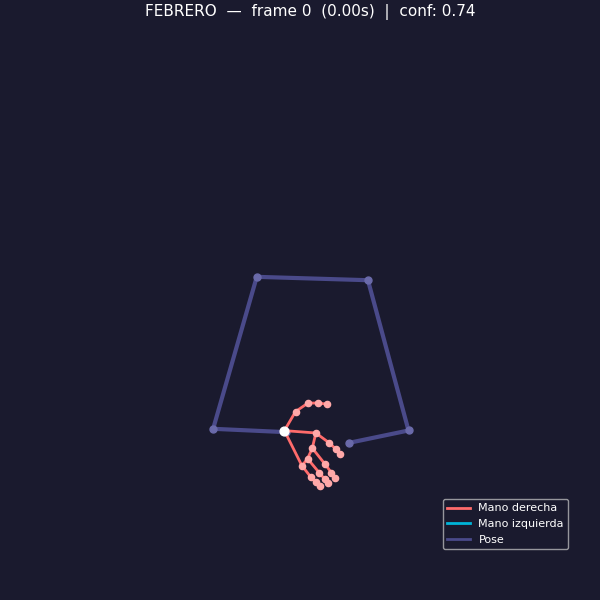

In [5]:
# ── Slider interactivo ─────────────────────────────────────────────────────────
%matplotlib widget

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(frames) - 1,
    step=1,
    description='Frame:',
    continuous_update=True,
    layout=widgets.Layout(width='600px')
)

play = widgets.Play(
    value=0,
    min=0,
    max=len(frames) - 1,
    step=1,
    interval=int(1000 / fps),  # ms entre frames
    description='Play',
)

widgets.jslink((play, 'value'), (slider, 'value'))

def on_frame_change(change):
    draw_frame(ax, frames[change['new']])
    fig.canvas.draw_idle()

slider.observe(on_frame_change, names='value')
draw_frame(ax, frames[0])

display(widgets.VBox([widgets.HBox([play, slider])]))
plt.show()